# Toy example with Geometric Brownian Motion Paths as data

## Paramters of the model (regression coefficient and scaling coefficient for feature normalisation may be added)

In [67]:
T = 1  # final time
N = 100  # number of time steps
M = 10  # number of paths to generate
mu = 1.0  # drift coefficient
sigma = 0.2  # volatility coefficient
depth = 8  # depth of the signature truncation
S = 0.9 * T  # observation time
S0 = 100 # initial value of the process
lambda_1 = 0.1  # regularization parameter for ridge regression, with paths_1
lambda_2 = 0.1  # regularization parameter for ridge regression, with paths_2
#prediction_type = "whole path"
prediction_type = "future path"

## Geometric Brownian motion as the solution to the SDE 
## $dS_t = \mu S_t dt+\sigma S_t dW_t$, then 
## $S_t = S_0\exp((\mu-\frac{\sigma^2}{2})t+\sigma W_t)$


In [68]:
#generating Geometric Brownian Motion (GBM) paths (augmented paths (t,x))

import numpy as np
import matplotlib.pyplot as plt

def generate_gbm_path(S0=100, mu=0.1, sigma=0.2, T=1, N=100):
    dt = T / N
    t = np.linspace(0, T, N)
    W = np.random.standard_normal(size=N)
    W = np.cumsum(W) * np.sqrt(dt)  # standard Brownian motion
    S = (mu - 0.5 * sigma**2) * t + sigma * W
    X = S0 * np.exp(S)
    X[0] = S0
    return X

def generate_gbm_data(S0=100, mu=0.1, sigma=0.2, T=1, N=100, M=5):
    t = np.linspace(0, T, N)
    X_samples = np.zeros((M+1, N))
    X_samples[0, :] =  t # set initial stock price for all paths
    #generate and plot M paths
    for i in range(1,M+1):    
        X = generate_gbm_path(S0, mu, sigma, T, N)
        X_samples[i, :] = X
    return X_samples


In [69]:
samples_of_X = generate_gbm_data(S0=S0, T=T, N=N, M=M, mu=mu, sigma=sigma)
t = samples_of_X[0, :]  # time vector for plotting
#For later use in testing we compute another set of paths with different parameters
X_test = generate_gbm_data(S0=S0, T=T, N=N, M=1, mu=mu, sigma=sigma)

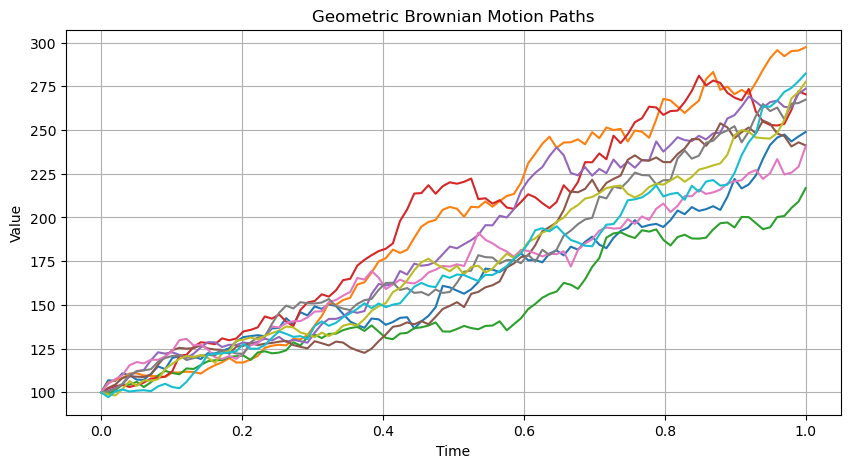

In [70]:
plt.figure(figsize=(10, 5))
for i in range(1,M+1):
    plt.plot(t, samples_of_X[i, :], label=f"Path {i+1}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Geometric Brownian Motion Paths")
#plt.legend()
plt.grid()
plt.show()

## Introduction of a observation horizon $S < T = 1$. Then split sample path $X$ in $X^S$ (regressor) and the whole path $X$ (regressand). The later is calles $Y=X$ in the literature so we rename $Y=X$ and $X=X^S$

In [71]:
def stopping(path: np.ndarray, T: float, N: int, S: float) -> np.ndarray:
    time = np.linspace(0, T, N)
    path_truncated = path[time < S]  # defines a mask, i.e. a boolean array which can be used for subsampling an array
    stopped_value = path_truncated[-1]
    n_pad = len(path) - len(path_truncated)
    path_stopped = np.concatenate([path_truncated, np.full(n_pad, stopped_value)])
    return path_stopped

def get_stopped_data(data, T, N, S):
    samples_of_X_stopped = np.zeros_like(data)
    for i in range(1, data.shape[0]):
        samples_of_X_stopped[i, :] = stopping(data[i, :], T, N, S)
    samples_of_X_stopped[0, :] = data[0, :]
    return samples_of_X_stopped

samples_of_X_stopped = get_stopped_data(samples_of_X, T, N, S)
#rename the latter for clarity in the context of regression (X,Y)
#recall X is stopped and Y is the original/full path, 
Y = samples_of_X
X = samples_of_X_stopped


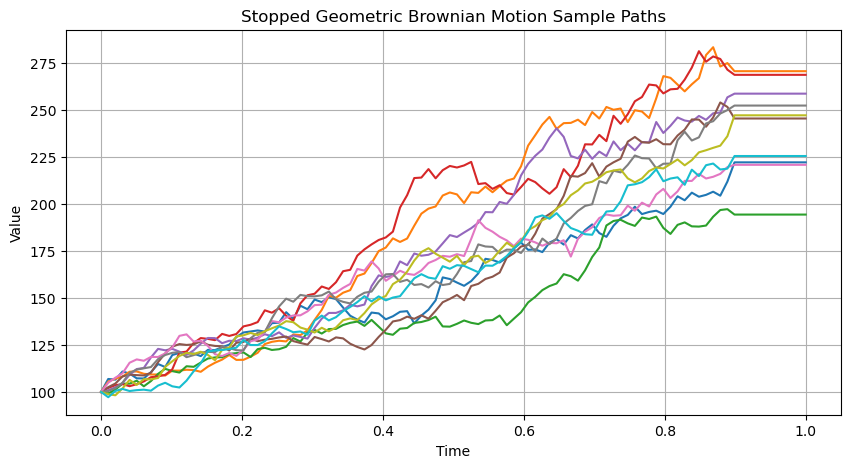

In [72]:
plt.figure(figsize=(10, 5))
for i in range(1, M+1):
    plt.plot(t, X[i, :], label=f"Stopped Path {i}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Stopped Geometric Brownian Motion Sample Paths")
plt.grid()
plt.show()

In [73]:
#define the test function f = pi_I where I is a subsample of points in [S,T] (points for which seek to predict the path)
#k = 10 # number of points in the subsample i.e. |I| = k 
#finally get the data of the form (x,y) and (y,f(y))=(y,(y_i_1,...y_i_k))
def get_sampled_paths(Y: np.ndarray, S: float) -> np.ndarray:
    t = Y[0, :]
    s = t[t < S]
    k = N - len(s)
    indices = np.sort(np.random.choice(np.arange(len(s), N), size=k, replace=False))#randomly select k indices between first time point after S and end point t = T (index N)
    return Y[:, indices]  # select values of the paths at the chosen indices (time points), has shape (M+1, k) (M paths and f_Y[0, :] are the sampled time points)

## For later, notice that in Algo I these values f(Y) are not to be scaled (not in a bounded signature)

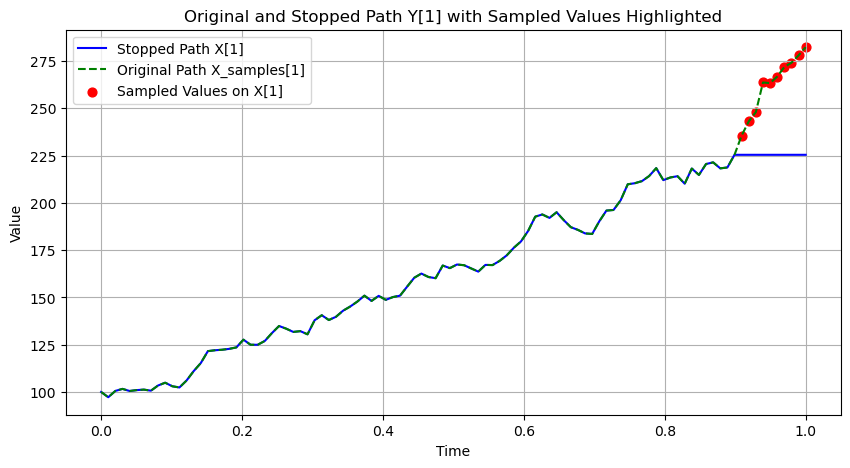

In [74]:
t = Y[0, :]
k = N - len(t[t < S])
indices = np.sort(np.random.choice(np.arange(len(t[t < S]), N), size=k, replace=False))
f_Y = get_sampled_paths(Y, S)  

j = M  # index of the path to plot
plt.figure(figsize=(10, 5))
plt.plot(t, X[j, :], label="Stopped Path X[1]", color="blue")
plt.plot(t, Y[j, :], label="Original Path X_samples[1]", color="green", linestyle="--")
# Highlight the values of X[1] at the sampled indices
#plt.scatter(t[indices], samples_of_X[j, indices], color="red", s=80, marker="o", label="Sampled Values on X[1]")
plt.scatter(t[indices], f_Y[j,:], color="red", s=40, marker="o", label="Sampled Values on X[1]")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Original and Stopped Path Y[1] with Sampled Values Highlighted")
plt.legend()
plt.grid()
plt.show()

# Introducing feature normalisation
## step 1: Defining $\psi$ (Oberhauser/Chevyrev, example 4)

In [75]:
# Implementing the feature normalization of Oberhauser and Chevyrev

def psi(x: float, a: float = 0.5, C: float = 2)->float:
    """
    Parameter range is a > 0 and C >= 1
    """
    y = x**2
    if y <= C:
        return y
    else: return C + (C**(1+a))*(C**(-a)+y**(-a))/a

## For $\mathbb{R}$-valued paths (our case: $k=1$) the tensor norm reduces to the euclidian norm

In [76]:
def norm_of_truncated_tensor_1d(t: np.ndarray) -> float:
    return np.sqrt(np.sum(t**2))

## step 2: Solving the polynomial in $\lambda$: $||\delta_{\lambda}sig(x)||^2=\psi(||sig(x)||)$, where $\delta_{\lambda}sig(x)=(\lambda^0\cdot sig^0(x),\lambda^1\cdot sig^1(x),\lambda^2\cdot sig^2(x),\dots)$

### Notice that for $\mathbb{R}$-valued paths $||\delta_{\lambda}sig(x)||=\sum_{i=0}^m |\int (dx)^i|^2$ where $\int (dx)^i = \int dx\cdots dx$ i times, hence we want to find the roots of (for truncation at level m)
### $Pol(\lambda)=(\sum_{i=0}^m |\lambda^{i}\cdot sig^i(x)|^2)-\psi(\sum_{i=0}^m |sig^i(x)|^2)$

In [77]:
from scipy.optimize import brentq

def root_finding_brent(signature_array: np.ndarray, target: float, tol: float = 1e-6, max_iter: int = 1000) -> float:
    """
    Solve pol(λ) = norm(mult(signature, λ)) - target = 0 for λ ≥ 0
    where mult(signature, λ) gives y[i] = λ^i * signature[i]
    """
    def polynomial(λ):
        if λ == 0:
            powers = np.zeros(len(signature_array))
        else:
            powers = λ ** np.arange(len(signature_array))
        weighted_signature = signature_array * powers  # sig_i * λ^i
        result = norm_of_truncated_tensor_1d(weighted_signature) - target  # Euclidean norm
        if np.isinf(result):
            return 1e15  # Return a large finite number instead of inf
        return result

    # Use Brent's method to find the root
    # Make sure that Pol(a) and Pol(b) have opposite signs (Pol(0)<= -1 garanteed so we need to check that Pol(b)>=0)
    a, b = 0.0, 1e6
    f_a = polynomial(a)
    f_b = polynomial(b)
    
    # Ensure opposite signs
    if f_a * f_b > 0:
        # Same signs - need to find better bounds
        # Since polynomial is monotonic increasing for λ ≥ 0,
        # and f_a < 0, we need to find where it becomes positive
        b = 1e6
        while polynomial(b) < 0 and b < 1e8:
            b *= 10
        if polynomial(b) < 0:
            raise ValueError("Could not find suitable upper bound")

    root = brentq(polynomial, a=0, b=1e6, xtol=tol, maxiter=max_iter)
    return root

## the bisection part of brent algorithm requires f(a) to have opposite sign than f(b).
## here we use the fact that psi(x):[1,infty)->[1,infty) and norm(0)=0 hence polynomial(0) = norm(0)-psi(...)<= -1)
## furthermore considering the explicit expression for the polynomial above, Pol(λ) is positive and monotoneous in λ, hence we expect pol(λ=1e6) a lot bigger than psi(||sig(x)||) which doesn't depend on λ.
## According to the latter argument there exists λ big enough such that pol(λ) > 0, but taking λ=1e6 is a works in practice but could fail in theory (if psi(||sig(x)||) is huge
## The above raises the value of λ and hopes to achive pol(λ)>0 at some point, otherwise raises an error.

### Notice the above has to be done for every path $X[j],j\geq 1$ separatly giving a different $\lambda$ for every such path. Now we scale the paths which implements the bounded signature due to $\delta_{\lambda}(sig(x))=sig(\lambda\cdot x)$

In [78]:
def compute_lambdas(sig_X):   
    lambdas = [] 
    for i in range(0, sig_X.shape[0]):
        norm_sig_X = norm_of_truncated_tensor_1d(sig_X[i, :])
        lambdas.append(root_finding_brent(sig_X[i, :], psi(norm_sig_X)))
    return np.array(lambdas).reshape(-1, 1)

In [79]:
## Defining the function to compute the augmented signatures already needed for the computation of lambdas
import jax
import signax

#takes as input (unaugmented path) with path[0] = t and paths path[j] for j between 1 and M+1, where M is the number of paths)
def compute_augmented_signatures(paths, depth):
    signatures = []
    for j in range(1, paths.shape[0]): #don't want to stack time with time so starting at j = 1 rather than j = 0
        paths_augmented = jax.numpy.stack([paths[0, :], paths[j, :]], axis=1)#need stack along axis 1 because in signax documentation input path has shape (length, dim). 
        sig = signax.signature(paths_augmented, depth=depth)
        signatures.append(sig)
    signatures = jax.numpy.stack(signatures)
    return signatures

In [80]:
# rescaling of the paths equivalent to rescaling signature in order to implement the bounded signature
def lambda_rescaling(paths: np.ndarray) -> np.ndarray:
    signature = compute_augmented_signatures(paths, depth)
    lambdas = compute_lambdas(signature)
    return paths[1:, :] * lambdas, lambdas

In [81]:
# normalizing the paths in order for better learning performance, emperically
def statistical_normalization(paths: np.ndarray) -> tuple:
    # emperical moments of the generated data
    Mean = np.mean(paths[1:, :], axis=1)  # mean of the stopped paths
    Std = np.std(paths[1:, :], axis=1)  # standard
    return (paths[1:, :] - Mean.reshape(-1, 1)) / Std.reshape(-1, 1), Mean, Std

In [82]:
X_original = X.copy()  # keep the original X for later use or debugging
Y_original = Y.copy()  # keep the original Y for later use or debugging
X_test_original = X_test.copy()  # keep the original X_test for later use or debugging

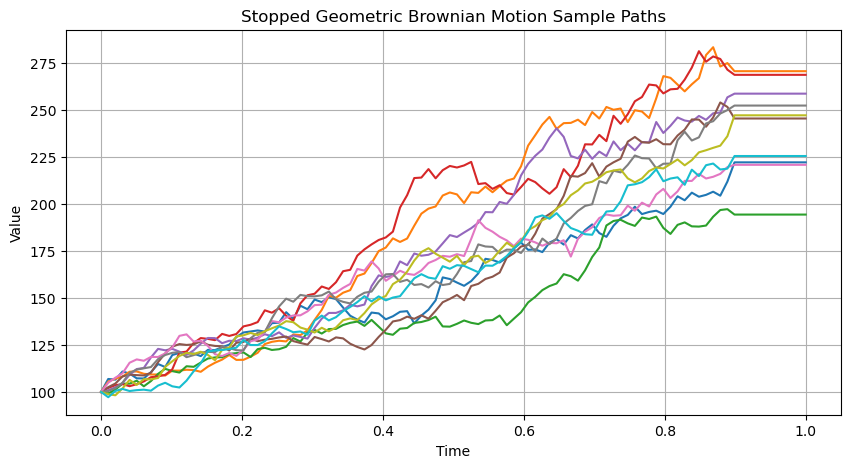

In [83]:
plt.figure(figsize=(10, 5))
for i in range(1, M+1):
    plt.plot(t, X[i, :], label=f"Stopped Path {i}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Stopped Geometric Brownian Motion Sample Paths")
plt.grid()
#plt.legend()
plt.show()

In [84]:
# Normalize the data for better learning performance
X[1:, :], mean_X, std_X = statistical_normalization(X) 
Y[1:, :], mean_Y, std_Y = statistical_normalization(Y) 
X_test[1:, :], mean_X_test, std_X_test = statistical_normalization(X_test)

# Remember to add the mean back to prediction

In [85]:
# Rescaling paths to implement bounded signature
X[1:, :], lambdas_X = lambda_rescaling(X)
Y[1:, :], lambdas_Y = lambda_rescaling(Y)
X_test[1:, :], lambdas_X_test = lambda_rescaling(X_test)

/var/folders/4g/6hk507fj4_z52gc5hhkkpdrr0000gn/T/ipykernel_95122/3293619238.py:12: RuntimeWarning: overflow encountered in power
  powers = λ ** np.arange(len(signature_array))


# Construction of matrices for normal equations
## Construction of data vector $B_{ij}=f_j(y_i)=(y_i)_{t_j}$

In [86]:
# recall that the first row in f_Y has the time values, which we want to remove to get the matrix B
def get_B(paths_2, S):
    if prediction_type == "future path":
        B = get_sampled_paths(paths_2, S)[1:, :]
    elif prediction_type == "whole path":
        B = paths_2[1:, :]
    return B
# Notice that B is the only object in Algo I that depends on the function f!

## Construction of the signature kernel matrices $A_X$: Signature Kernel with $X$, $A_Y$: Signature Kernel with $Y$

In [87]:
## Computing signature kernel matrices of augmented paths
import jax.numpy as jnp
from powersig.jax.algorithm import PowerSigJax

def powersig_kernel_matrix_augmented(paths, depth):
    augmented_paths = jnp.stack([jnp.stack([paths[0, :], paths[j, :]], axis=1) for j in range(1, paths.shape[0])])
    powersig = PowerSigJax(depth)
    return powersig(augmented_paths)


## Construction of the Signature matrix $C$

In [88]:
## Dimension of the truncated tensor algebra (m_d in Algo I). In our case, the data is 1-dimensional, so we set d = 1.

def dimensionality_regression(depth, dimension_data):
    """
    Function to compute the dimensionality of the regression problem.
    For d > 1, m_d = (d^{m+1} - 1) / (d - 1)
    For d = 1, m_d = M
    """
    if dimension_data > 1:
        return (dimension_data ** (depth + 1) - 1) / (dimension_data - 1)
    else:
        return depth  # M for d = 1
        

## Solving the normal equations

In [89]:
from sklearn.linear_model import ridge_regression

def regression_coeffs(paths_1, paths_2, lambda_1 = 1.0, lambda_2 = 1.0):
    # Compute the matrices for regression
    m_d = dimensionality_regression(depth, 1)
    C = compute_augmented_signatures(paths_2,m_d)
    B = get_B(paths_2, S)
    # Compute the kernel matrices for the augmented paths
    kernel_matrix_aug_1 = powersig_kernel_matrix_augmented(paths_1, depth)
    kernel_matrix_aug_2 = powersig_kernel_matrix_augmented(paths_2, depth)
    # Perform ridge regression to find coefficients
    beta = ridge_regression(kernel_matrix_aug_1, C, alpha=lambda_1*M)
    alpha = ridge_regression(kernel_matrix_aug_2, B, alpha=lambda_2*M)
    if B.shape[1] == 1:#if we perform single value prediction reshape alpha to ensure it has shape (M, 1) and not (M,)
        alpha = alpha.reshape(-1, 1)
        return alpha, beta, C
    else:
        return alpha, beta, C

# Construction of estimator $\psi_f = \sum_l\sum_k \alpha_{kl} \langle sig_m(Y[l]),\Upsilon\rangle\cdot e_k$

## kernel_vec $_j=\langle sig(X[j, :]),sig(X_{test})\rangle$ 

In [90]:
# Inner product in definition of psi_f

def signature_kernel_vector(paths, path_new, order=8):

    augmented_paths = jnp.stack([jnp.stack([paths[0, :], paths[j, :]], axis=1) for j in range(1, paths.shape[0])])  # (M, N, 2)
    augmented_paths_new = jnp.stack([path_new[0, :], path_new[1, :]], axis=1).reshape(1, path_new.shape[1], 2)  # (1, N, 2)
    powersig = PowerSigJax(order)
    kernel_vector = powersig(augmented_paths, augmented_paths_new)
    return kernel_vector

## Construction of estimator $\Upsilon=\sum_i\sum_j\beta_{ji}\cdot$ (kernel_vec) $_j e_i$

In [91]:
def signature_estimator(paths_1, paths_2, paths_new, lambda_1=1.0, lambda_2=1.0):
    kernel_vec = signature_kernel_vector(paths_1, paths_new, order=8)
    alpha, beta, C = regression_coeffs(paths_1, paths_2, lambda_1=lambda_1, lambda_2=lambda_2)
    sig_est = jnp.dot(beta, kernel_vec)
    return sig_est, alpha, C

In [92]:
def estimator(paths_1, paths_2, paths_new, lambda_1=1.0, lambda_2=1.0):
    sig_est, alpha, C = signature_estimator(paths_1, paths_2, paths_new, lambda_1=lambda_1, lambda_2=lambda_2)
    return (alpha @ C @ sig_est).reshape(1, -1)

In [93]:
## predicted values at t_pred using the estimator on the test path
pred_values = estimator(X, Y, X_test, lambda_1, lambda_2)

# Notice that taking larger values of lambda_1 and lambda_2 leads to more regularized predictions, i.e. smoother paths.

In [94]:
#rescaling prediction to original scale, by inverting statistical normalization and lambda rescaling. Mind the order of operations!
pred_values_rescaled = (pred_values / lambdas_X_test[0]) * std_X_test + mean_X_test

In [95]:
# compute RMSE of the prediction
def compute_rmse(values, path):
    t = path[0, :]  # time vector for the test paths
    if prediction_type == "whole path":
        # Compute RMSE for whole path predictions
        rmse = np.sqrt(np.mean((values - path) ** 2))
    elif prediction_type == "future path":
        # Compute RMSE for future path predictions
        rmse = np.sqrt(np.mean((values[0] - path[:, t >= S]) ** 2))
    return rmse

In [96]:
print(compute_rmse(pred_values_rescaled, X_test_original))

213.38375819060968


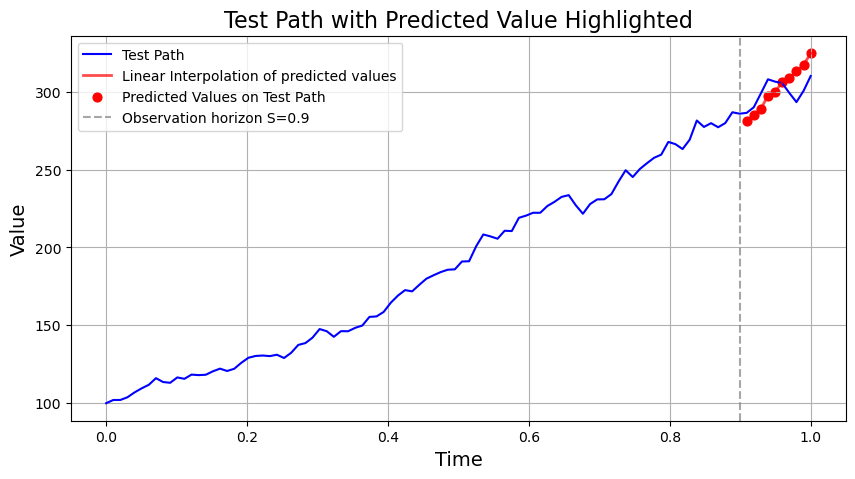

In [97]:
# Plot for 'whole path' prediction type
# Adjusting for initial offset (which doesn't seem to be learned well by the model)
plt.figure(figsize=(10, 5))
plt.plot(t, X_test_original[1, :], label="Test Path", color="blue")
if prediction_type == "whole path":
    t_pred = t
    plt.plot(t_pred, pred_values_rescaled[0, :], color="red", linestyle="-", alpha=0.7, linewidth=2, label="Linear Interpolation of predicted values")
    plt.scatter(t_pred, pred_values_rescaled[0, :], color="red", s=40, marker="o", label="Predicted Values on Test Path")
elif prediction_type == "future path":
    t_pred = t[indices]
    plt.plot(t_pred, pred_values_rescaled[0, :], color="red", linestyle="-", alpha=0.7, linewidth=2, label="Linear Interpolation of predicted values")
    plt.scatter(t_pred, pred_values_rescaled[0, :], color="red", s=40, marker="o", label="Predicted Values on Test Path")
    #plt.plot(t_pred, pred_values_rescaled_shifted[0, :], color="red", linestyle="-", alpha=0.7, linewidth=2, label="Linear Interpolation of predicted values")
    #plt.scatter(t_pred, pred_values_rescaled_shifted[0, :], color="red", s=40, marker="o", label="Predicted Values on Test Path")

plt.axvline(x=S, color='gray', linestyle='--', alpha=0.7, label=f'Observation horizon S={S}')

plt.xlabel("Time", fontsize=14)
plt.ylabel("Value", fontsize=14)
plt.title("Test Path with Predicted Value Highlighted", fontsize=16)
plt.grid()
plt.legend()
plt.show()

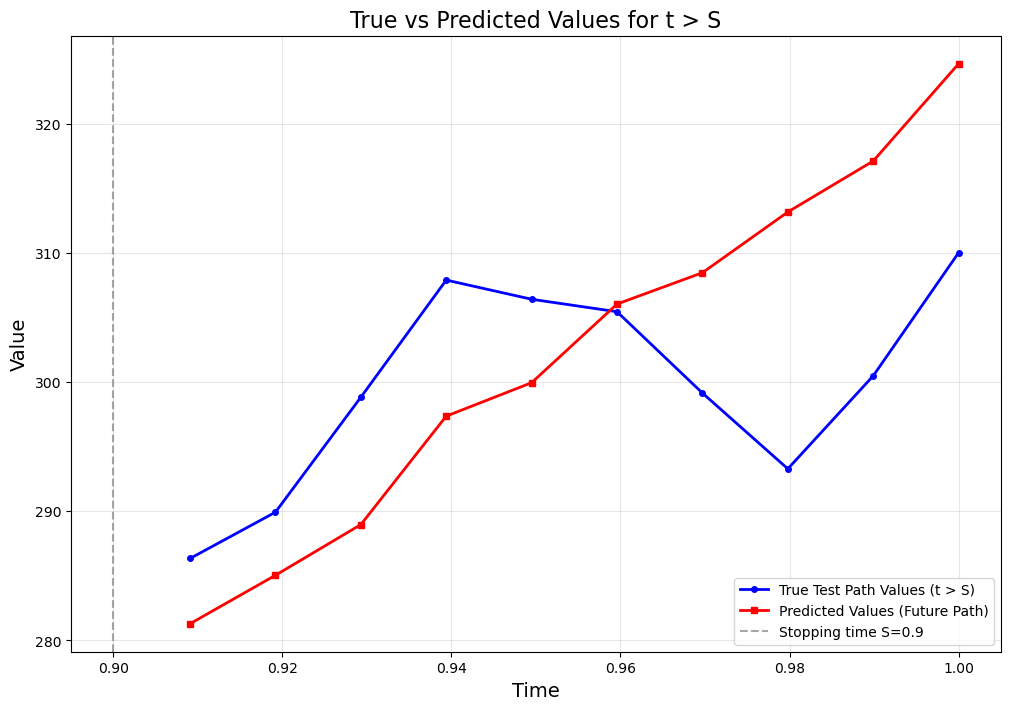

Prediction type: future path
Number of time points with t > S: 10
Number of predicted points: 10
Time range for predictions: 0.909 to 1.000
Time range for t > S: 0.909 to 1.000
True values range: 286.349 to 310.022


In [98]:
# Combined plot for X_test_original and predicted values for t>S
plt.figure(figsize=(12, 8))

# Get time points for prediction region
t_pred_region = t[t > S]

if prediction_type == "future path":
    # For future path prediction, get the indices and corresponding predicted values
    t_pred_indices = t[indices]  # Time points where predictions were made
    pred_values_to_plot = pred_values_rescaled[0, :] if 'pred_values_rescaled_shifted' in locals() else pred_values_rescaled[0, :]
    #pred_values_to_plot = pred_values_rescaled_shifted[0, :] if 'pred_values_rescaled_shifted' in locals() else pred_values_rescaled[0, :]
    
    # Plot true values for t>S
    plt.plot(t_pred_region, X_test_original[1, t > S], 'b-', linewidth=2, marker='o', markersize=4, label='True Test Path Values (t > S)')
    
    # Plot predicted values
    plt.plot(t_pred_indices, pred_values_to_plot, 'r-', linewidth=2, marker='s', markersize=4, label='Predicted Values (Future Path)')
    
elif prediction_type == "whole path":
    # For whole path prediction, use all time points > S
    plt.plot(t_pred_region, X_test_original[1, t > S], 'b-', linewidth=2, marker='o', markersize=4, label='True Test Path Values (t > S)')
    plt.plot(t_pred_region, pred_values_rescaled[0, t > S], 'r-', linewidth=2, marker='s', markersize=4, label='Predicted Values (Whole Path)')

# Add vertical line at stopping time
plt.axvline(x=S, color='gray', linestyle='--', alpha=0.7, label=f'Stopping time S={S}')

plt.xlabel('Time', fontsize=14)
plt.ylabel('Value', fontsize=14)
plt.title('True vs Predicted Values for t > S', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print some statistics
print(f"Prediction type: {prediction_type}")
print(f"Number of time points with t > S: {len(t_pred_region)}")
if prediction_type == "future path":
    print(f"Number of predicted points: {len(pred_values_rescaled[0, :])}")
    print(f"Time range for predictions: {t_pred_indices[0]:.3f} to {t_pred_indices[-1]:.3f}")
print(f"Time range for t > S: {t_pred_region[0]:.3f} to {t_pred_region[-1]:.3f}")
print(f"True values range: {X_test_original[1, t > S].min():.3f} to {X_test_original[1, t > S].max():.3f}")

## Averaging RMSE over 10 repetitions for every M[i] in M_ for one and the same test path

In [ ]:
import matplotlib.pyplot as plt

# Get true values at prediction points
T = 1.0  # final time
S = 0.95 * T  # observation time
M_ = [10, 20, 50, 70, 100, 120, 150, 170, 200]

rmse_ = np.zeros((len(M_), 10))
N = 200
X_test_rmse = generate_gbm_data(S0=S0, T=T, N=N, M=1, mu=mu, sigma=sigma)
X_test_original = X_test_rmse.copy()
t = X_test[0, :]

# Storage for condition numbers
kappa_Az = np.zeros((len(M_), 10))
kappa_Ay = np.zeros((len(M_), 10))

# Computation of condition number of the relevant matrices for ridge regression (the one's a)
def cond_ridge(K, alpha):
    K = np.array(K)
    A = K.T @ K + alpha * np.eye(K.shape[0])  # K is MxM here
    s = np.linalg.svd(A, compute_uv=False)
    # guard against zeros (shouldn’t occur with α>0, but just in case)
    return float(s.max() / s.min()) if np.all(s > 0) else np.inf

for i in range(0, len(M_)):
    M_current = M_[i]
    for j in range(0, 10):  
        #Generate new training data with M_current paths
        Y_current = generate_gbm_data(S0=S0, T=T, N=N, M=M_current, mu=mu, sigma=sigma) 
        time = Y_current[0, :]  # time vector for plotting
        # Apply stopping
        X_current =  get_stopped_data(Y_current, T, N, S)
        # Normalize the data
        X_current[1:, :], mean_X, std_X = statistical_normalization(X_current)
        Y_current[1:, :], mean_Y, std_Y = statistical_normalization(Y_current)
        X_test_rmse[1:, :], mean_X_test, std_X_test = statistical_normalization(X_test_rmse)

        X_current[1:, :], lambdas_X = lambda_rescaling(X_current)
        Y_current[1:, :], lambdas_Y = lambda_rescaling(Y_current)
        X_test_rmse[1:, :], lambdas_X_test = lambda_rescaling(X_test_rmse)

        # Compute κ2 for both Gram matrices at this (i,j) position
        Kz = powersig_kernel_matrix_augmented(X_current, depth)  # A_z (X-side)
        Ky = powersig_kernel_matrix_augmented(Y_current, depth)  # A_y (Y-side)
        alpha_z = lambda_1 * M_current
        alpha_y = lambda_2 * M_current
        kappa_Az[i, j] = cond_ridge(Kz, alpha_z)
        kappa_Ay[i, j] = cond_ridge(Ky, alpha_y)

        # Make prediction and rescale it
        pred_values = estimator(X_current, Y_current, X_test_rmse, lambda_1, lambda_2)
        pred_values_rescaled = (pred_values / lambdas_X_test[0]) * std_X_test + mean_X_test


        rmse_current = np.sqrt(np.mean((pred_values - X_test_original[1, len(time[time<S]):])**2))
        rmse_[i, j] = rmse_current

/var/folders/4g/6hk507fj4_z52gc5hhkkpdrr0000gn/T/ipykernel_95122/3293619238.py:12: RuntimeWarning: overflow encountered in power
  powers = λ ** np.arange(len(signature_array))
/var/folders/4g/6hk507fj4_z52gc5hhkkpdrr0000gn/T/ipykernel_95122/3293619238.py:12: RuntimeWarning: overflow encountered in power
  powers = λ ** np.arange(len(signature_array))


KeyboardInterrupt: 

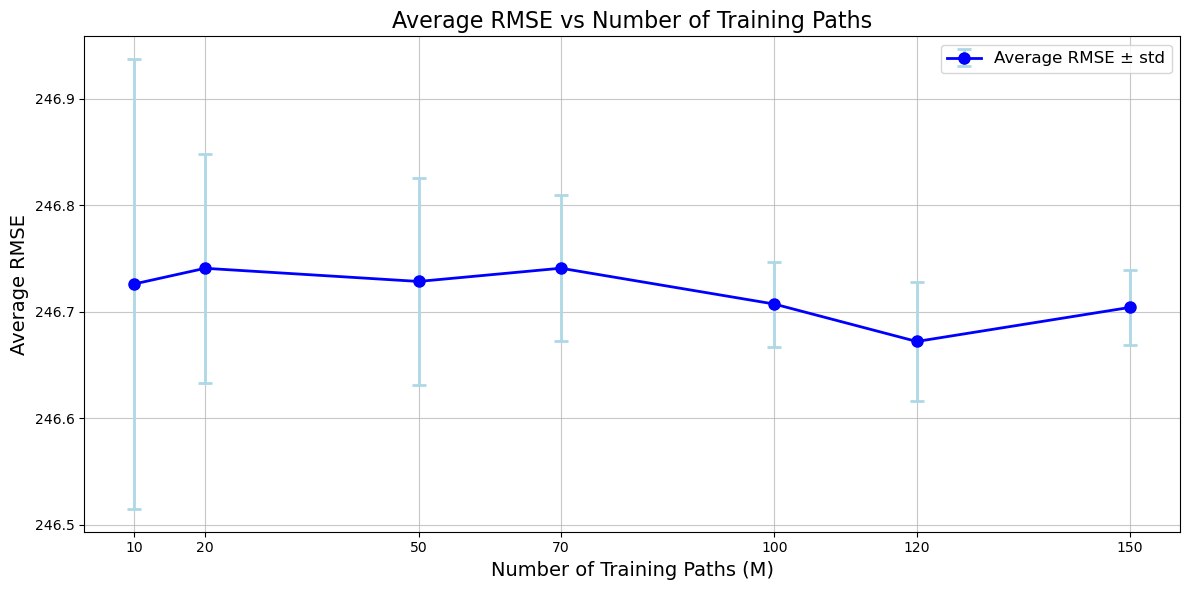

In [ ]:
average_rmse = np.mean(rmse_, axis=1)
std_rmse = np.std(rmse_, axis=1)

plt.figure(figsize=(12, 6))
plt.errorbar(M_, average_rmse, yerr=std_rmse, marker='o', linestyle='-', 
             linewidth=2, markersize=8, capsize=5, capthick=2,
             color='blue', ecolor='lightblue', label='Average RMSE ± std')
plt.xlabel("Number of Training Paths (M)", fontsize=14)
plt.ylabel("Average RMSE", fontsize=14)
plt.title("Average RMSE vs Number of Training Paths", fontsize=16)
plt.xticks(M_)
plt.grid(True, alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

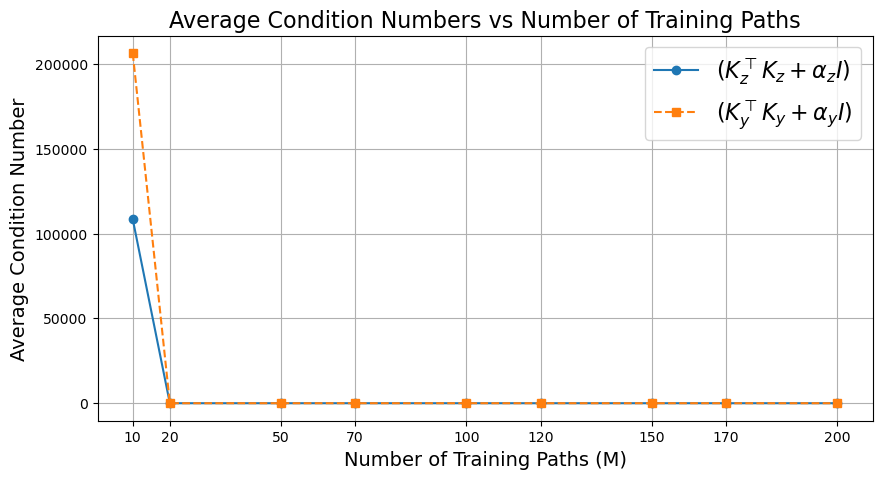

In [100]:
avg_kappa_Az = kappa_Az.mean(axis=1)
avg_kappa_Ay = kappa_Ay.mean(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(M_, avg_kappa_Az, marker='o', linestyle='-', label=r'$(K_z^\top K_z + \alpha_z I)$')
plt.plot(M_, avg_kappa_Ay, marker='s', linestyle='--', label=r'$(K_y^\top K_y + \alpha_y I)$')
plt.xlabel("Number of Training Paths (M)", fontsize=14)
plt.ylabel("Average Condition Number", fontsize=14)
plt.title("Average Condition Numbers vs Number of Training Paths", fontsize=16)
plt.xticks(M_)
plt.grid()
plt.legend(fontsize=16)
plt.show()

In [ ]:
# Save the array
np.save('average_rmse_GBM_NPSR_10_20_50_70_100_120_150__N_200.npy', average_rmse)

# Later, load it back
#average_rmse = np.load('average_rmse_GBM_NPSR_10_20_50_70_100_120_150__N_200.npy')

FileNotFoundError: [Errno 2] No such file or directory: 'average_rmse_GBM_NPSR_10_20_50_70_100_120_150__N_200.npy'